In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [4]:
df = pd.read_csv("version 1.csv")

In [5]:
df.head()

,Actual data of,Day of the week,Max. Demand at eve. peak (Generation end),Max. Demand at eve. peak (Sub-station end),Highest Generation (Generation end),Minimum Generation (Generation end),Day-peak Generation (Generation end),Evening-peak Generation (Generation end),Minimum Generation Forecast up to 8:00 hrs.,Maximum Temperature in Dhaka was,...,Barishal_load,Rangpur_demand,Rangpur_supply,Rangpur_load,Cumilla_demand,Cumilla_supply,Cumilla_load,Khulna_demand,Khulna_supply,Khulna_load
0,21.11.19,Thursday,8785.0,8110.0,8785.0,5647.0,7294.7,8785.0,5475.9,29.6,...,0.0,208.0,208.0,0.0,701.0,701.0,0.0,953.0,953.0,0.0
1,22.11.19,Friday,7886.0,7344.0,7886.0,5283.5,5725.9,7886.0,5200.0,29.3,...,0.0,201.0,201.0,0.0,694.0,694.0,0.0,908.0,908.0,0.0
2,23.11.19,Saturday,8827.0,8197.0,8827.0,5200.0,6731.7,8946.0,5470.0,28.8,...,0.0,210.0,210.0,0.0,729.0,729.0,0.0,974.0,974.0,0.0
3,24.11.19,Sunday,8855.0,8224.0,8855.0,5470.0,7062.8,8855.0,5500.0,29.1,...,0.0,216.0,216.0,0.0,722.0,722.0,0.0,983.0,983.0,0.0
4,25.11.19,Monday,8982.0,8356.0,8978.0,5500.0,7110.7,8982.0,5609.0,29.0,...,0.0,219.0,219.0,0.0,735.0,735.0,0.0,981.0,981.0,0.0


In [6]:
df.shape

(1848, 41)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1848 entries, 0 to 1847
Data columns (total 41 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   Actual data of                               1847 non-null   object 
 1   Day of the week                              1847 non-null   object 
 2   Max. Demand at eve. peak (Generation end)    1847 non-null   float64
 3   Max. Demand at eve. peak (Sub-station end)   1847 non-null   float64
 4   Highest Generation (Generation end)          1847 non-null   float64
 5   Minimum Generation (Generation end)          1847 non-null   float64
 6   Day-peak Generation (Generation end)         1847 non-null   float64
 7   Evening-peak Generation (Generation end)     1847 non-null   float64
 8   Minimum Generation Forecast up to 8:00 hrs.  1847 non-null   float64
 9   Maximum Temperature in Dhaka was             1843 non-null   float64
 10  

In [8]:
#rename first column
df.rename(columns={df.columns[0]: 'Date'}, inplace=True)


In [9]:
df.columns = df.columns.str.strip()

In [31]:
df.drop(columns= df.columns[df.isnull().all()], inplace=True)


In [11]:
df['Date'] = pd.to_datetime(df['Date'], format='%d.%m.%y', errors='coerce')

In [32]:

print(df.isnull().sum())

Day of the week       0
Max_Demand_Gen_End    0
Max_Demand_SS_End     0
Highest_Generation    0
Min_Generation        0
                     ..
Cumilla_load          0
Khulna_demand         0
Khulna_supply         0
Khulna_load           0
Daily_Loss_Rate       0
Length: 41, dtype: int64


In [ ]:
print("\n--- Final Cleaned DataFrame Info ---")
df.info()
print("\n--- Final Head ---")
print(df.head())


--- Final Cleaned DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1848 entries, 0 to 1847
Data columns (total 41 columns):
 #   Column                                       Non-Null Count  Dtype         
---  ------                                       --------------  -----         
 0   Date                                         1847 non-null   datetime64[ns]
 1   Day of the week                              1847 non-null   object        
 2   Max. Demand at eve. peak (Generation end)    1847 non-null   float64       
 3   Max. Demand at eve. peak (Sub-station end)   1847 non-null   float64       
 4   Highest Generation (Generation end)          1847 non-null   float64       
 5   Minimum Generation (Generation end)          1847 non-null   float64       
 6   Day-peak Generation (Generation end)         1847 non-null   float64       
 7   Evening-peak Generation (Generation end)     1847 non-null   float64       
 8   Minimum Generation Forecast up to 8:00 h

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1848 entries, 0 to 1847
Data columns (total 41 columns):
 #   Column                                       Non-Null Count  Dtype         
---  ------                                       --------------  -----         
 0   Date                                         1847 non-null   datetime64[ns]
 1   Day of the week                              1847 non-null   object        
 2   Max. Demand at eve. peak (Generation end)    1847 non-null   float64       
 3   Max. Demand at eve. peak (Sub-station end)   1847 non-null   float64       
 4   Highest Generation (Generation end)          1847 non-null   float64       
 5   Minimum Generation (Generation end)          1847 non-null   float64       
 6   Day-peak Generation (Generation end)         1847 non-null   float64       
 7   Evening-peak Generation (Generation end)     1847 non-null   float64       
 8   Minimum Generation Forecast up to 8:00 hrs.  1847 non-null   float64       
 9

In [15]:
# Create a dictionary to map the old, messy names to simple, clean names
column_mapping = {
    'Max. Demand at eve. peak (Generation end)': 'Max_Demand_Gen_End',
    'Max. Demand at eve. peak (Sub-station end)': 'Max_Demand_SS_End',
    'Highest Generation (Generation end)': 'Highest_Generation',
    'Minimum Generation (Generation end)': 'Min_Generation',
    'Day-peak Generation (Generation end)': 'Day_Peak_Generation',
    'Evening-peak Generation (Generation end)': 'Eve_Peak_Generation',
    'Minimum Generation Forecast up to 8:00 hrs.': 'Min_Gen_Forecast_0800',
    'Maximum Temperature in Dhaka was': 'Max_Temp_Dhaka',
    'Gas/LF limitation': 'Gas_LF_Limitation',
    'Coal supply Limitation': 'Coal_Limitation',
    'Low water level in Kaptai lake': 'Kaptai_Water_Low',
    'Plants under shut down/ maintenance': 'Plants_Shutdown_Maint',
    
    # Regional columns (These are already fairly clean and follow the pattern Region_metric)
}

# Rename the columns in your DataFrame
df.rename(columns=column_mapping, inplace=True)
print("Columns successfully renamed.")

Columns successfully renamed.


In [16]:
df.head()

,Date,Day of the week,Max_Demand_Gen_End,Max_Demand_SS_End,Highest_Generation,Min_Generation,Day_Peak_Generation,Eve_Peak_Generation,Min_Gen_Forecast_0800,Max_Temp_Dhaka,...,Barishal_load,Rangpur_demand,Rangpur_supply,Rangpur_load,Cumilla_demand,Cumilla_supply,Cumilla_load,Khulna_demand,Khulna_supply,Khulna_load
0,2019-11-21,Thursday,8785.0,8110.0,8785.0,5647.0,7294.7,8785.0,5475.9,29.6,...,0.0,208.0,208.0,0.0,701.0,701.0,0.0,953.0,953.0,0.0
1,2019-11-22,Friday,7886.0,7344.0,7886.0,5283.5,5725.9,7886.0,5200.0,29.3,...,0.0,201.0,201.0,0.0,694.0,694.0,0.0,908.0,908.0,0.0
2,2019-11-23,Saturday,8827.0,8197.0,8827.0,5200.0,6731.7,8946.0,5470.0,28.8,...,0.0,210.0,210.0,0.0,729.0,729.0,0.0,974.0,974.0,0.0
3,2019-11-24,Sunday,8855.0,8224.0,8855.0,5470.0,7062.8,8855.0,5500.0,29.1,...,0.0,216.0,216.0,0.0,722.0,722.0,0.0,983.0,983.0,0.0
4,2019-11-25,Monday,8982.0,8356.0,8978.0,5500.0,7110.7,8982.0,5609.0,29.0,...,0.0,219.0,219.0,0.0,735.0,735.0,0.0,981.0,981.0,0.0


In [33]:
mean_temp = df['Max_Temp_Dhaka'].mean()
df['Max_Temp_Dhaka'].fillna(mean_temp, inplace=True)

C:\Users\HP\AppData\Local\Temp\ipykernel_9168\2783536404.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Max_Temp_Dhaka'].fillna(mean_temp, inplace=True)


In [18]:
df.fillna(method='ffill', inplace=True)

C:\Users\HP\AppData\Local\Temp\ipykernel_9168\3970806690.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


In [19]:
df.set_index('Date', inplace=True)

In [20]:
# --- Final Check ---
print("\n--- Final Missing Value Check (Should be 0) ---")
print(df.isnull().sum().max()) # Prints the maximum number of NaNs left

print("\n--- Final Head with Date as Index ---")
print(df.head())


--- Final Missing Value Check (Should be 0) ---
0

--- Final Head with Date as Index ---
           Day of the week  Max_Demand_Gen_End  Max_Demand_SS_End  \
Date                                                                
2019-11-21        Thursday              8785.0             8110.0   
2019-11-22          Friday              7886.0             7344.0   
2019-11-23        Saturday              8827.0             8197.0   
2019-11-24          Sunday              8855.0             8224.0   
2019-11-25          Monday              8982.0             8356.0   

            Highest_Generation  Min_Generation  Day_Peak_Generation  \
Date                                                                  
2019-11-21              8785.0          5647.0               7294.7   
2019-11-22              7886.0          5283.5               5725.9   
2019-11-23              8827.0          5200.0               6731.7   
2019-11-24              8855.0          5470.0               7062.8   


In [21]:
# Temporarily set Pandas to display all columns and rows
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 10) # Set this higher if you want to see more rows

In [22]:
print(df.head())

           Day of the week  Max_Demand_Gen_End  Max_Demand_SS_End  \
Date                                                                
2019-11-21        Thursday              8785.0             8110.0   
2019-11-22          Friday              7886.0             7344.0   
2019-11-23        Saturday              8827.0             8197.0   
2019-11-24          Sunday              8855.0             8224.0   
2019-11-25          Monday              8982.0             8356.0   

            Highest_Generation  Min_Generation  Day_Peak_Generation  \
Date                                                                  
2019-11-21              8785.0          5647.0               7294.7   
2019-11-22              7886.0          5283.5               5725.9   
2019-11-23              8827.0          5200.0               6731.7   
2019-11-24              8855.0          5470.0               7062.8   
2019-11-25              8978.0          5500.0               7110.7   

            Eve_Pe

In [23]:
# Save the final cleaned DataFrame to a new CSV file
# index=True saves the 'Date' column as the first column in the CSV
df.to_csv('final_clean_power_data.csv')
print("\nFinal clean data saved to 'final_clean_power_data.csv'")


Final clean data saved to 'final_clean_power_data.csv'


In [24]:
df.head()

,Day of the week,Max_Demand_Gen_End,Max_Demand_SS_End,Highest_Generation,Min_Generation,Day_Peak_Generation,Eve_Peak_Generation,Min_Gen_Forecast_0800,Max_Temp_Dhaka,Gas_LF_Limitation,Coal_Limitation,Kaptai_Water_Low,Plants_Shutdown_Maint,Dhaka_demand,Dhaka_supply,Dhaka_load,Chattogram_demand,Chattogram_supply,Chattogram_load,Rajshahi_demand,Rajshahi_supply,Rajshahi_load,Mymensingh_demand,Mymensingh_supply,Mymensingh_load,Sylhet_demand,Sylhet_supply,Sylhet_load,Barishal_demand,Barishal_supply,Barishal_load,Rangpur_demand,Rangpur_supply,Rangpur_load,Cumilla_demand,Cumilla_supply,Cumilla_load,Khulna_demand,Khulna_supply,Khulna_load
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2019-11-21,Thursday,8785.0,8110.0,8785.0,5647.0,7294.7,8785.0,5475.9,29.6,1349.0,0.0,0.0,470.0,3214.0,3214.0,0.0,905.0,905.0,0.0,953.0,953.0,0.0,639.0,639.0,0.0,329.0,329.0,0.0,208.0,208.0,0.0,208.0,208.0,0.0,701.0,701.0,0.0,953.0,953.0,0.0
2019-11-22,Friday,7886.0,7344.0,7886.0,5283.5,5725.9,7886.0,5200.0,29.3,1164.0,0.0,0.0,470.0,2686.0,2686.0,0.0,813.0,813.0,0.0,908.0,908.0,0.0,613.0,613.0,0.0,320.0,320.0,0.0,201.0,201.0,0.0,201.0,201.0,0.0,694.0,694.0,0.0,908.0,908.0,0.0
2019-11-23,Saturday,8827.0,8197.0,8827.0,5200.0,6731.7,8946.0,5470.0,28.8,1114.0,0.0,0.0,470.0,3223.0,3223.0,0.0,897.0,897.0,0.0,974.0,974.0,0.0,652.0,652.0,0.0,328.0,328.0,0.0,210.0,210.0,0.0,210.0,210.0,0.0,729.0,729.0,0.0,974.0,974.0,0.0
2019-11-24,Sunday,8855.0,8224.0,8855.0,5470.0,7062.8,8855.0,5500.0,29.1,1204.0,0.0,0.0,555.0,3248.0,3248.0,0.0,883.0,883.0,0.0,983.0,983.0,0.0,646.0,646.0,0.0,327.0,327.0,0.0,216.0,216.0,0.0,216.0,216.0,0.0,722.0,722.0,0.0,983.0,983.0,0.0
2019-11-25,Monday,8982.0,8356.0,8978.0,5500.0,7110.7,8982.0,5609.0,29.0,1255.0,0.0,0.0,555.0,3346.0,3346.0,0.0,878.0,878.0,0.0,981.0,981.0,0.0,669.0,669.0,0.0,328.0,328.0,0.0,219.0,219.0,0.0,219.0,219.0,0.0,735.0,735.0,0.0,981.0,981.0,0.0


In [25]:
#all the details (date, day, demand, generation, etc.) for the day with the highest generation demand

max_row = df[df['Max_Demand_Gen_End'] == df['Max_Demand_Gen_End'].max()]
print(max_row)


           Day of the week  Max_Demand_Gen_End  Max_Demand_SS_End  \
Date                                                                
2024-04-29          Monday             17200.0            16417.0   

            Highest_Generation  Min_Generation  Day_Peak_Generation  \
Date                                                                  
2024-04-29             15595.0         11993.0              13036.0   

            Eve_Peak_Generation  Min_Gen_Forecast_0800  Max_Temp_Dhaka  \
Date                                                                     
2024-04-29              15595.0                13148.0            40.5   

            Gas_LF_Limitation  Coal_Limitation  Kaptai_Water_Low  \
Date                                                               
2024-04-29             1035.0              0.0             200.0   

            Plants_Shutdown_Maint  Dhaka_demand  Dhaka_supply  Dhaka_load  \
Date                                                                     

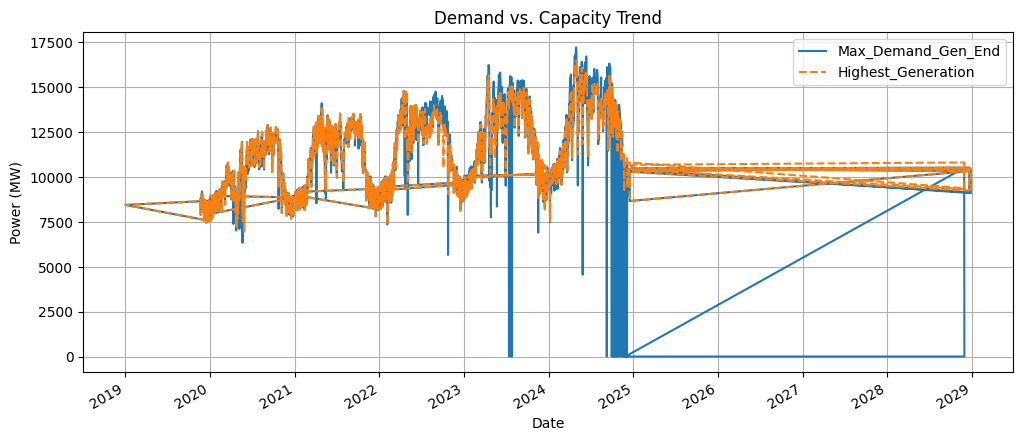

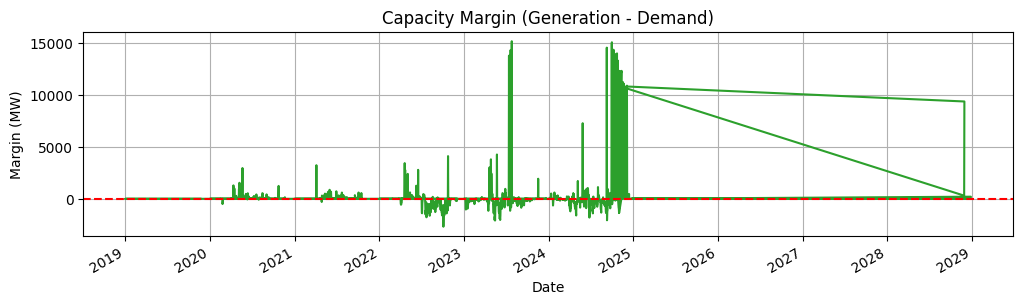

In [26]:
# Plot 1: Demand vs. Generation Trend
df[['Max_Demand_Gen_End', 'Highest_Generation']].plot(
    figsize=(12, 5), 
    title='Demand vs. Capacity Trend', 
    ylabel='Power (MW)', 
    grid=True,
    style=['-', '--'] # Solid line for demand, dashed for capacity
)
plt.show()

# Plot 2: Capacity Margin (Generation - Demand)
(df['Highest_Generation'] - df['Max_Demand_Gen_End']).plot(
    figsize=(12, 3), 
    title='Capacity Margin (Generation - Demand)', 
    ylabel='Margin (MW)', 
    grid=True, 
    color='tab:green'
)
plt.axhline(0, color='red', linestyle='--') # Add the zero margin line
plt.show()

In [27]:
# 1. Calculate the difference (swing) for each day
daily_operational_swing = df['Highest_Generation'] - df['Min_Generation']

# 2. Calculate the mean of that daily difference
average_operational_swing = daily_operational_swing.mean()

print(f"Average Daily Operational Swing: {average_operational_swing:.2f} MW")

Average Daily Operational Swing: 3243.21 MW


In [28]:
# 1. Calculate the prediction error (Forecast - Actual) for each day
prediction_error = df['Min_Gen_Forecast_0800'] - df['Min_Generation']

In [29]:
# 2. Calculate the Mean Absolute Error (MAE) 
# The .abs() ensures all errors are treated as positive for better accuracy measurement.
mean_abs_error = prediction_error.abs().mean()

# 3. Calculate the Mean Error (Bias) 
mean_error = prediction_error.mean()

print(f"Average Prediction Error (Bias): {mean_error:.2f} MW")
print(f"Average Absolute Prediction Error (MAE): {mean_abs_error:.2f} MW")

Average Prediction Error (Bias): 23.61 MW
Average Absolute Prediction Error (MAE): 438.06 MW


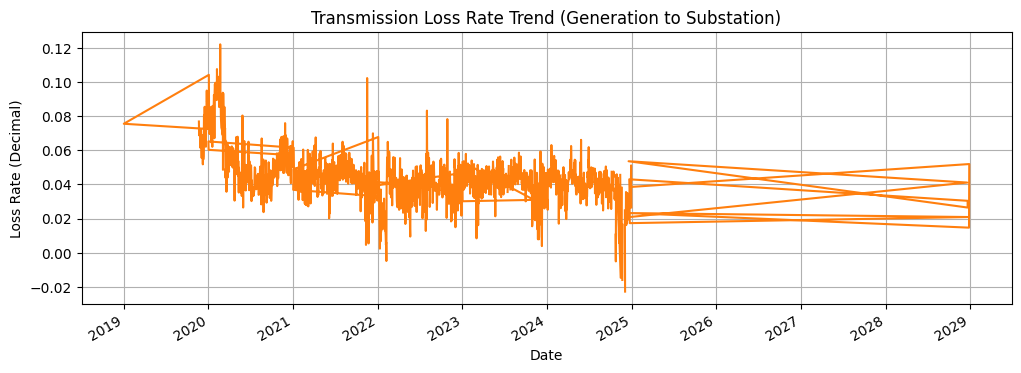

In [30]:
# 1. Calculate the daily transmission loss rate (Generation - Substation) / Generation
df['Daily_Loss_Rate'] = (df['Max_Demand_Gen_End'] - df['Max_Demand_SS_End']) / df['Max_Demand_Gen_End']

# 2. Plot the trend of the loss rate over time
df['Daily_Loss_Rate'].plot(
    figsize=(12, 4), 
    title='Transmission Loss Rate Trend (Generation to Substation)', 
    ylabel='Loss Rate (Decimal)', 
    grid=True,
    color='tab:orange'
)
plt.show()
